# Dimension of Solution Space

Or the degrees of freedom in optimization. We don't distiguish the nuances here.


## Distance in Transformed Space

For the discussion of degrees of freedom, let us consider a linear transformation associated with a matrix $A[1,2,3]^T$ from a 3D space to a 1D space. This trasformation mappes the unit cube to a line segment. (See the figure below)

Confirm the distances $\|A[x, y, z]^T - b\|$ in the mapped space such as mapped v3 and "b" or mapped v8 and "b", the former is 4 and the latter is zero.

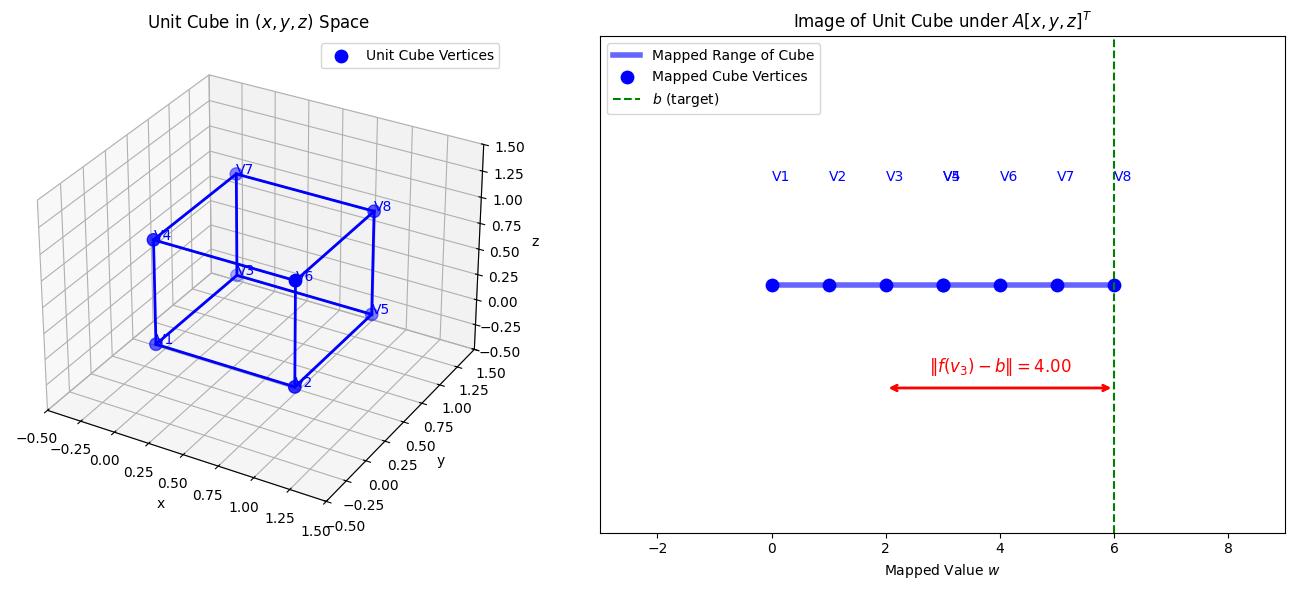

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

A = np.array([[1, 2, 3]])
b = np.array([6])

# Vertices of the unit cube
cube_vertices = np.array([
    [0, 0, 0],
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [1, 1, 0],
    [1, 0, 1],
    [0, 1, 1],
    [1, 1, 1]
])

# Edges of the unit cube (pairs of vertex indices)
cube_edges = [
    (0,1), (0,2), (0,3),
    (1,4), (1,5),
    (2,4), (2,6),
    (3,5), (3,6),
    (4,7), (5,7), (6,7)
]

end_points = np.array([(-0.5, -0.5, -0.5), (1.5, 1.5, 1.5)])
mapped_end_points = (A @ end_points.T).flatten()

# Sample random points in a larger box for context
np.random.seed(42)
with_box_points = False
if with_box_points:
    n_points = 300
    box_points = np.random.uniform(-0.5, 1.5, size=(n_points, 3))
    mapped_box = (A @ box_points.T).flatten()

# Map each vertex through A
mapped_cube = (A @ cube_vertices.T).flatten()  # shape (8,)

fig = plt.figure(figsize=(14,6))

# 3D plot: show the unit cube in a larger space
ax = fig.add_subplot(121, projection='3d')
# Draw bounding box for context
ax.plot([0,1,1,0,0], [0,0,1,1,0], [0,0,0,0,0], 'k--', alpha=0.3)  # bottom
ax.plot([0,1,1,0,0], [0,0,1,1,0], [1,1,1,1,1], 'k--', alpha=0.3)  # top
for z in [0,1]:
    for x in [0,1]:
        ax.plot([x,x], [0,1], [z,z], 'k--', alpha=0.3)
    for y in [0,1]:
        ax.plot([0,1], [y,y], [z,z], 'k--', alpha=0.3)
# Draw cube edges
for i,j in cube_edges:
    ax.plot(
        [cube_vertices[i,0], cube_vertices[j,0]],
        [cube_vertices[i,1], cube_vertices[j,1]],
        [cube_vertices[i,2], cube_vertices[j,2]],
        color='blue', lw=2
    )
# Plot the unit cube vertices
ax.scatter(cube_vertices[:,0], cube_vertices[:,1], cube_vertices[:,2], color='blue', s=80, label='Unit Cube Vertices')
for i, (x, y, z) in enumerate(cube_vertices):
    ax.text(x, y, z, f'V{i+1}', color='blue', fontsize=10)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_zlim(-0.5, 1.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Unit Cube in $(x, y, z)$ Space')
ax.legend()

# 2D plot: mapped values as a line segment, with background points
ax2 = fig.add_subplot(122)
if with_box_points:
    ax2.scatter(mapped_box, np.zeros_like(mapped_box), color='gray', s=10, alpha=0.2, label='Mapped Box Points')
cube_min, cube_max = mapped_cube.min(), mapped_cube.max()
ax2.plot([cube_min, cube_max], [0,0], 'blue', lw=4, alpha=0.6, label='Mapped Range of Cube')
ax2.scatter(mapped_cube, np.zeros_like(mapped_cube), color='blue', s=80, label='Mapped Cube Vertices')
for i, w in enumerate(mapped_cube):
    ax2.text(w, 0.05, f'V{i+1}', color='blue', fontsize=10)
ax2.axvline(b[0], color='green', linestyle='--', label='$b$ (target)')
ax2.set_yticks([])
ax2.set_xlabel('Mapped Value $w$')
ax2.set_title('Image of Unit Cube under $A[x, y, z]^T$')
ax2.set_xlim(mapped_end_points)
ax2.set_ylim(-0.12, 0.12)
ax2.legend()

# Index for V3 (third vertex)
v3_idx = 2
v3_mapped = mapped_cube[v3_idx]
b_val = b[0]

# Draw arrow from V3 to b
arrow_y = -0.05  # vertical offset for arrow
ax2.annotate(
    '', xy=(b_val, arrow_y), xytext=(v3_mapped, arrow_y),
    arrowprops=dict(arrowstyle='<->', color='red', lw=2)
)
# Add text label for the norm
ax2.text(
    (v3_mapped + b_val)/2, arrow_y+0.005,
    fr'$ \|f(v_3) - b\| = {abs(v3_mapped - b_val):.2f}$',
    color='red', fontsize=12, ha='center', va='bottom'
)

plt.tight_layout()
plt.show()

## Example: A Problem with Two Degrees of Freedom

Now, let us consider the distance mimization problem. What are the points which minimize $ \|A[x, y, z]^T - b\| $?

The figure below visualizes the objective function $ f(x, y, z) = ||A[x, y, z]^T - b|| $ for an underdetermined linear system, where $A$ is a $1 \times 3$ matrix and $b$ is a scalar. In this case, the set of points that satisfy $x + 2y + 3z = 6$ forms a plane in 3D space. All points on this plane are solutions that minimize the objective function, and they are highlighted in blue. Points not on the plane have higher values of $f(x, y, z)$, shown by different colors.

This example illustrates the concept of degrees of freedom in optimization problems. The degrees of freedom refer to the number of independent variables that can be adjusted to find a solution. Here, there are two degrees of freedom, so the solution space is a plane. In general, more degrees of freedom mean more ways to vary the solution while still satisfying the constraints.

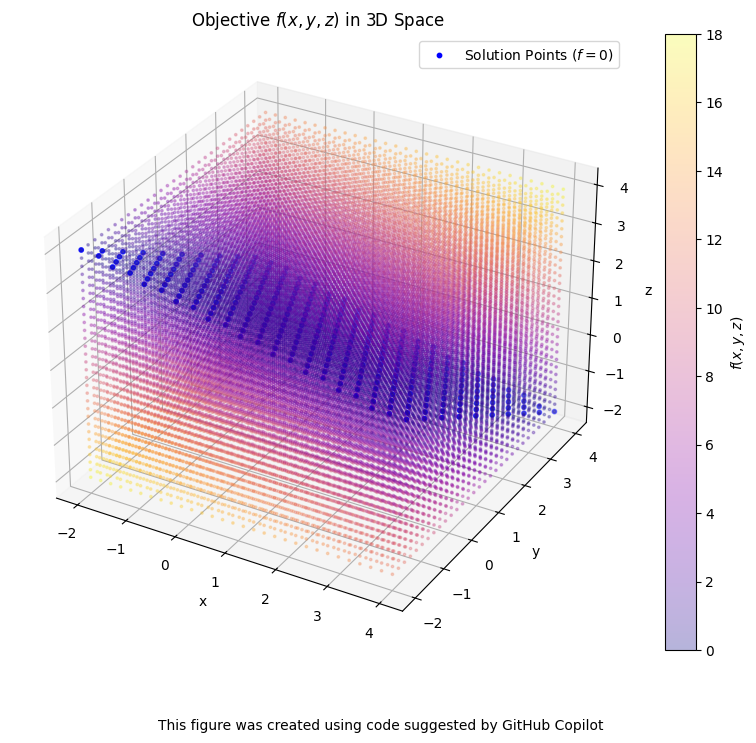

In [2]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[1, 2, 3]])
b = np.array([6])

# Grid for plotting
x = np.linspace(-2, 4, 30)
y = np.linspace(-2, 4, 30)
z = np.linspace(-2, 4, 30)
X, Y, Z = np.meshgrid(x, y, z)

def f(x, y, z):
    v = np.stack([x, y, z], axis=-1)
    diff = np.dot(v, A.T) - b
    return np.linalg.norm(diff, axis=-1)

F = f(X, Y, Z)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Plot all points, color by value
sc = ax.scatter(X.flatten(), Y.flatten(), Z.flatten(), c=F.flatten(), cmap='plasma', s=3, alpha=0.3)
plt.colorbar(sc, label='$f(x, y, z)$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Objective $f(x, y, z)$ in 3D Space')

# Highlight the solution points (where f is close to zero)
mask = F.flatten() < 1e-6
ax.scatter(X.flatten()[mask], Y.flatten()[mask], Z.flatten()[mask], color='blue', s=10, label='Solution Points ($f=0$)')
ax.legend()

# Attribution
plt.figtext(0.5, 0.01, "This figure was created using code suggested by GitHub Copilot", ha="center", fontsize=10)

plt.show()

```{note}
This section, including its code and explanations, was created using suggestions from GitHub Copilot. Reaching this final state required many prompts with trial-and-error attempts.
```